# UNR tenv3 EDA → xarray NetCDF (header-aware)

This notebook:
- Summarizes the **download manifest**
- Reads UNR `.tenv3` files using the **header line** (robust to column re-ordering)
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype


plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [2]:
DATA_DIR = Path("./data/unr_tenv3_na")          # directory containing *.tenv3
MANIFEST = Path("./data/unr_outputs_na/manifest.csv")   # produced by downloader

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
assert MANIFEST.exists(), f"Missing {MANIFEST.resolve()}"
print("OK:", DATA_DIR, MANIFEST)


OK: data\unr_tenv3_na data\unr_outputs_na\manifest.csv


## 2) Manifest summary

In [3]:
manifest = pd.read_csv(MANIFEST)
display(manifest.head())

print("Total:", len(manifest))
print(manifest["status"].value_counts())


,station,url,status,http_status,bytes,path,error
0,ABBY,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,downloaded,200,264588.0,data\unr_tenv3_na\ABBY.NA.tenv3,NaN
1,ABOT,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,downloaded,200,356388.0,data\unr_tenv3_na\ABOT.NA.tenv3,NaN
2,AGNS,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,downloaded,200,333132.0,data\unr_tenv3_na\AGNS.NA.tenv3,NaN
3,AL2H,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,downloaded,200,573852.0,data\unr_tenv3_na\AL2H.NA.tenv3,NaN
4,ALB4,https://geodesy.unr.edu/gps_timeseries/IGS20/t...,downloaded,200,411264.0,data\unr_tenv3_na\ALB4.NA.tenv3,NaN


Total: 604
status
downloaded    603
not_found       1
Name: count, dtype: int64


## 3) Header-aware UNR tenv3 reader

In [11]:
def _normalize_col(c: str) -> str:
    c = re.sub(r"\s+", "_", c.strip())
    c = re.sub(r"_+", "_", c)
    return c.strip("_").lower()

def read_tenv3_headered(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        header = ""
        for line in f:
            line = line.strip()
            if line:
                header = line
                break
    if not header:
        raise ValueError(f"No header found in {path}")

    cols = [_normalize_col(x) for x in header.split()]

    df = pd.read_csv(
        path,
        sep='\\s+',
        names=cols,
        skiprows=1,
        comment="#",
        engine="python",
    )
    return df

def tenv3_to_clean(df: pd.DataFrame) -> pd.DataFrame:
    dec_year = pd.to_numeric(df["yyyy.yyyy"], errors="coerce")
    time = pd.to_datetime(df['yymmmdd'], format='%y%b%d')
    out = pd.DataFrame({
        "dec_year": dec_year,
        "time": time,
        "east_m": pd.to_numeric(df["east(m)"], errors="coerce"),
        "north_m": pd.to_numeric(df["north(m)"], errors="coerce"),
        "up_m": pd.to_numeric(df["up(m)"], errors="coerce"),
        "east_sigma_m": pd.to_numeric(df["sig_e(m)"], errors="coerce"),
        "north_sigma_m": pd.to_numeric(df["sig_n(m)"], errors="coerce"),
        "up_sigma_m": pd.to_numeric(df["sig_u(m)"], errors="coerce"),
    })

    out = out.dropna(subset=["dec_year", "east_m", "north_m", "up_m"]).reset_index(drop=True)
    return out


## 4) Inspect one station

In [12]:
# Treat downloaded + skipped_existing as "usable"
manifest["status_norm"] = manifest["status"].astype(str).str.strip().str.lower()

ok = manifest[manifest["status_norm"].isin({"downloaded", "skipped_existing"})].copy()
assert len(ok) > 0, "No usable stations (downloaded or skipped_existing) in manifest."

sample_station = ok.iloc[0]["station"]
path = DATA_DIR / f"{sample_station}.NA.tenv3"

raw = read_tenv3_headered(path)
ts = tenv3_to_clean(raw)

display(ts.head())
print("Rows:", len(ts))
print("Span (years):", float(ts.dec_year.max() - ts.dec_year.min()))

,dec_year,time,east_m,north_m,up_m,east_sigma_m,north_sigma_m,up_sigma_m
0,2015.3511,2015-05-09,0.803926,0.710908,0.290391,0.000884,0.001342,0.003771
1,2015.3539,2015-05-10,0.802524,0.708782,0.290452,0.000694,0.000994,0.002991
2,2015.3566,2015-05-11,0.802202,0.708968,0.294340,0.000710,0.001034,0.003005
3,2015.3593,2015-05-12,0.801961,0.708021,0.295943,0.000723,0.001068,0.003170
4,2015.3621,2015-05-13,0.801374,0.707813,0.293462,0.000769,0.001072,0.003278


Rows: 1296
Span (years): 7.646799999999985


#### verification plot

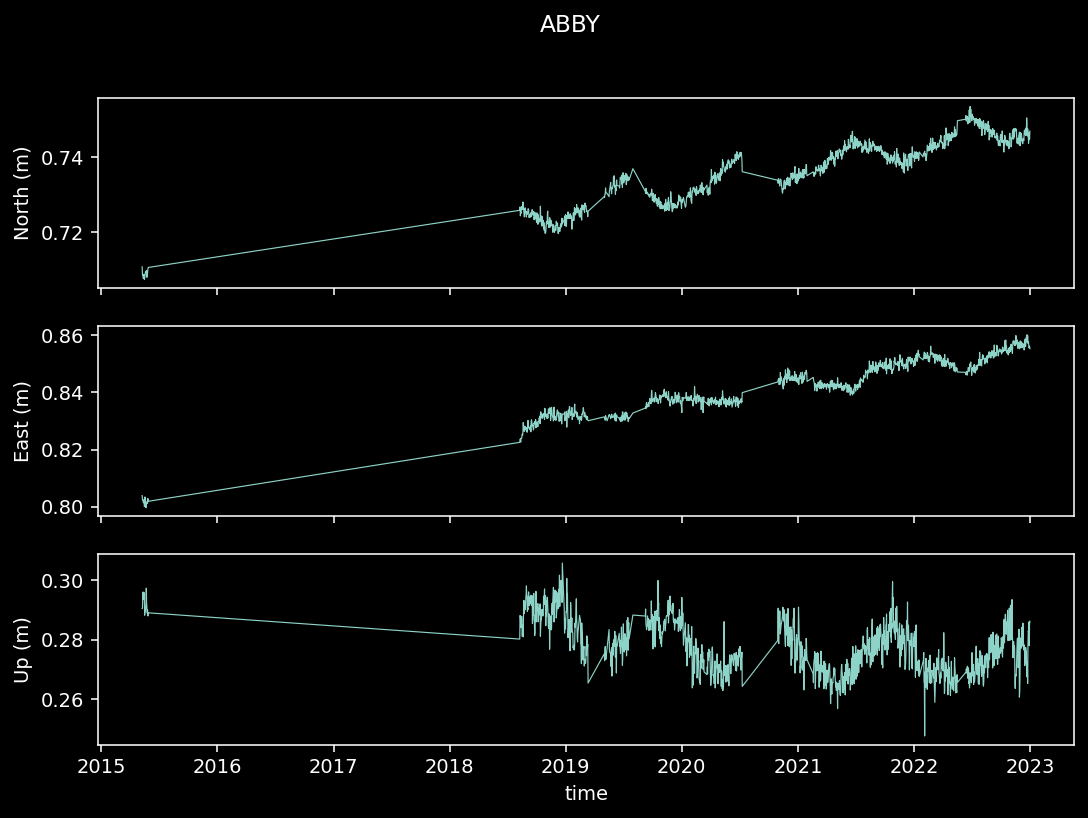

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(ts.time, ts.north_m, lw=0.6)
ax[0].set_ylabel("North (m)")

ax[1].plot(ts.time, ts.east_m, lw=0.6)
ax[1].set_ylabel("East (m)")

ax[2].plot(ts.time, ts.up_m, lw=0.6)
ax[2].set_ylabel("Up (m)")
ax[2].set_xlabel("time")

plt.suptitle(sample_station)
plt.show()


## 5) Apply filters: 2010→present and >5 years

In [16]:
station_list = pd.read_csv("./resources/catalog_subset_bbox.csv")
station_list

,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637
...,...,...,...,...
599,YCS2,46.941249,-122.590563,91.426696
600,YELM,46.948717,-122.605735,81.993392
601,YOCR,45.379102,-121.743553,1884.269527
602,YONC,43.634111,-123.298301,86.491947


In [19]:
START_YEAR = 2010.0
END_YEAR = 2025 + 1
MIN_YEARS = 5.0

def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()

def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)

ts_by_station = {}   # <-- canonical output of Section 5
fail = []            # (station, filename, error)
missing_on_disk = [] # stations listed in CSV but file not found

for st in station_list.name.astype(str).str.strip().str.lower().tolist():
    p = DATA_DIR / f"{st}.NA.tenv3"  # adjust if .enu etc
    if not p.exists():
        missing_on_disk.append(st)
        continue

    try:
        ts = read_tenv3_headered(p)
        ts = tenv3_to_clean(ts)
        ts = filter_window(ts)

        if has_min_span(ts):
            ts_by_station[st] = ts
        else:
            fail.append((st, p.name, f"Span < {MIN_YEARS}y after filtering"))
    except Exception as e:
        fail.append((st, p.name, str(e)))

valid_stations = sorted(ts_by_station.keys())
print(f"Valid stations loaded: {len(valid_stations)}")
print(f"Missing on disk: {len(missing_on_disk)}")
print(f"Failed (parse/filter/span): {len(fail)}")


Valid stations loaded: 486
Missing on disk: 1
Failed (parse/filter/span): 117


In [20]:
if missing_on_disk:
    print("\n--- Missing on disk (first 50) ---")
    for s in missing_on_disk[:50]:
        print(" ", s)

if fail:
    print("\n--- Failed (first 20) ---")
    for st, fname, err in fail[:20]:
        print(f" {st} ({fname}): {err}")



--- Missing on disk (first 50) ---
  c046

--- Failed (first 20) ---
 agns (agns.NA.tenv3): Span < 5.0y after filtering
 aldr (aldr.NA.tenv3): Span < 5.0y after filtering
 bcco (bcco.NA.tenv3): Span < 5.0y after filtering
 bcdn (bcdn.NA.tenv3): Span < 5.0y after filtering
 bclg (bclg.NA.tenv3): Span < 5.0y after filtering
 bcpm (bcpm.NA.tenv3): Span < 5.0y after filtering
 bcsk (bcsk.NA.tenv3): Span < 5.0y after filtering
 bcut (bcut.NA.tenv3): Span < 5.0y after filtering
 bcvt (bcvt.NA.tenv3): Span < 5.0y after filtering
 blvu (blvu.NA.tenv3): Span < 5.0y after filtering
 brnb (brnb.NA.tenv3): Span < 5.0y after filtering
 ca1r (ca1r.NA.tenv3): Span < 5.0y after filtering
 cacy (cacy.NA.tenv3): Span < 5.0y after filtering
 cafl (cafl.NA.tenv3): Span < 5.0y after filtering
 cami (cami.NA.tenv3): Span < 5.0y after filtering
 cayk (cayk.NA.tenv3): Span < 5.0y after filtering
 ccrt (ccrt.NA.tenv3): Span < 5.0y after filtering
 cedr (cedr.NA.tenv3): Span < 5.0y after filtering
 chco (chco.

## 6) xarray Dataset with dims (time, station) and station coords from catalog


In [22]:
list_ds = []
fail = []

for st, tmp_df in ts_by_station.items():
    try:
        df = tmp_df.copy()

        # build time index
        df = df.set_index("time").sort_index()

        # drop columns you don't want as data vars (optional)
        # df = df.drop(columns=["yr", "dayofyr", "dec_yr"], errors="ignore")

        # convert to xarray and add station dimension
        ds_st = df.to_xarray().expand_dims(station=[st])

        list_ds.append(ds_st)

    except Exception as e:
        fail.append((st, str(e)))

ds = xr.concat(list_ds, dim="station", join="outer").sortby("time")

print(f"Stations concatenated: {ds.sizes['station']}")
print(f"Time steps (union):    {ds.sizes['time']}")
if fail:
    print(f"Failed stations:       {len(fail)} (first 10 below)")
    for st, err in fail[:10]:
        print(" ", st, "->", err)

ds

Stations concatenated: 486
Time steps (union):    5840


<xarray.Dataset> Size: 159MB
Dimensions:        (station: 486, time: 5840)
Coordinates:
  * station        (station) object 4kB 'abby' 'abot' 'al2h' ... 'yonc' 'zse1'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
Data variables:
    dec_year       (station, time) float64 23MB nan nan ... 2.026e+03 2.026e+03
    east_m         (station, time) float64 23MB nan nan nan ... 0.8202 0.8188
    north_m        (station, time) float64 23MB nan nan nan ... 0.3457 0.3467
    up_m           (station, time) float64 23MB nan nan nan ... 0.6345 0.6276
    east_sigma_m   (station, time) float64 23MB nan nan ... 0.000691 0.000696
    north_sigma_m  (station, time) float64 23MB nan nan ... 0.000996 0.000974
    up_sigma_m     (station, time) float64 23MB nan nan nan ... 0.003091 0.00312

## 7) Station coords from catalog (CSV)

In [23]:
station_list["station"] = station_list["name"].astype(str).str.strip().str.lower()
station_list = station_list.set_index("station")

station_list_aligned = station_list.reindex(ds.station.to_numpy())

ds = ds.assign_coords(
    lat=("station", station_list_aligned["lat"].to_numpy(dtype=np.float64)),
    lon=("station", station_list_aligned["lon"].to_numpy(dtype=np.float64)),
    elev_m=("station", station_list_aligned["elev_m"].to_numpy(dtype=np.float64)),
)
ds

<xarray.Dataset> Size: 159MB
Dimensions:        (station: 486, time: 5840)
Coordinates:
  * station        (station) object 4kB 'abby' 'abot' 'al2h' ... 'yonc' 'zse1'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    lat            (station) float64 4kB 49.07 49.03 48.39 ... 45.38 43.63 47.29
    lon            (station) float64 4kB -122.2 -122.3 -123.5 ... -123.3 -122.2
    elev_m         (station) float64 4kB 195.3 -4.009 31.75 ... 86.49 82.06
Data variables:
    dec_year       (station, time) float64 23MB nan nan ... 2.026e+03 2.026e+03
    east_m         (station, time) float64 23MB nan nan nan ... 0.8202 0.8188
    north_m        (station, time) float64 23MB nan nan nan ... 0.3457 0.3467
    up_m           (station, time) float64 23MB nan nan nan ... 0.6345 0.6276
    east_sigma_m   (station, time) float64 23MB nan nan ... 0.000691 0.000696
    north_sigma_m  (station, time) float64 23MB nan nan ... 0.000996 0.000974
    up_sigma_m     (station, time) float64 23MB nan nan nan ... 0.003091 0.00312

## 8) Write NetCDF (UNR)

In [24]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_unr_2010_2025_5y_NA.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
ds.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_unr_2010_2025_5y_NA.nc


## 9) Smoke test: reopen and plot one station

<xarray.Dataset> Size: 159MB
Dimensions:        (station: 486, time: 5840)
Coordinates:
  * station        (station) <U4 8kB 'abby' 'abot' 'al2h' ... 'yonc' 'zse1'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    lat            (station) float64 4kB ...
    lon            (station) float64 4kB ...
    elev_m         (station) float64 4kB ...
Data variables:
    dec_year       (station, time) float64 23MB ...
    east_m         (station, time) float64 23MB ...
    north_m        (station, time) float64 23MB ...
    up_m           (station, time) float64 23MB ...
    east_sigma_m   (station, time) float64 23MB ...
    north_sigma_m  (station, time) float64 23MB ...
    up_sigma_m     (station, time) float64 23MB ...


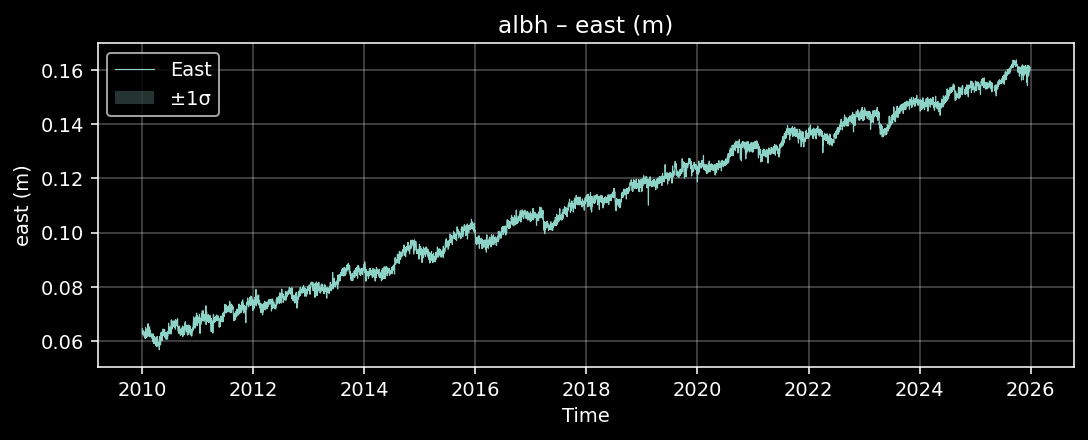

In [26]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "albh"
sel = ds.sel(station=st)

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.time, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.time,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("Time")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


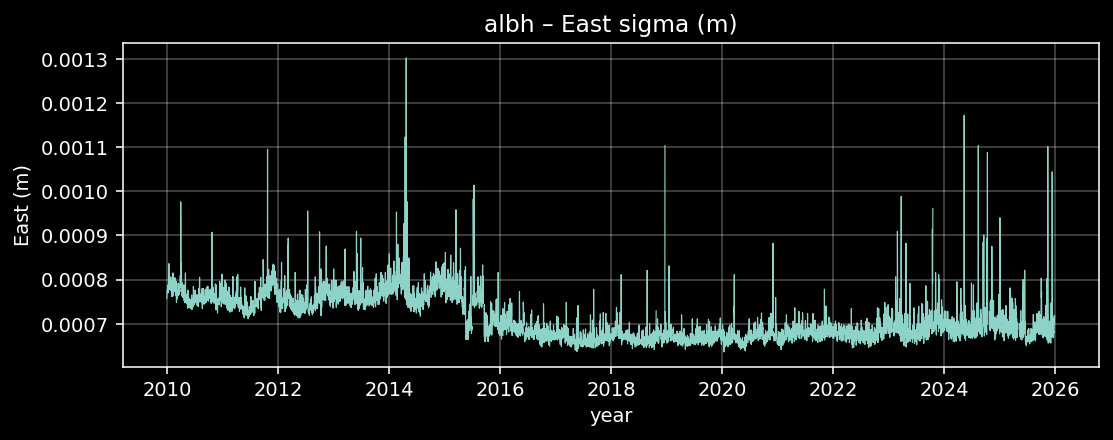

In [27]:
plt.figure(figsize=(9,3))
plt.plot(sel.time, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()

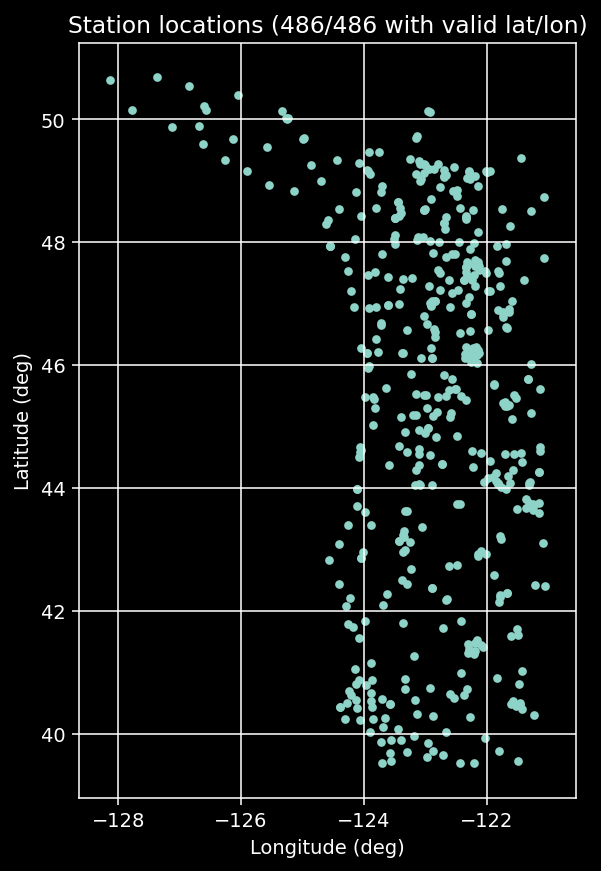

In [28]:
# --- grab station coords ---
lon = ds["lon"].values
lat = ds["lat"].values

mask = np.isfinite(lon) & np.isfinite(lat)
n_total = lon.size
n_ok = int(mask.sum())

# --- plot ---
plt.figure(figsize=(9, 7))
plt.scatter(lon[mask], lat[mask], s=12)  # (no explicit color per your style rule)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

# nice bounds with padding
if n_ok > 0:
    xmin, xmax = np.nanmin(lon[mask]), np.nanmax(lon[mask])
    ymin, ymax = np.nanmin(lat[mask]), np.nanmax(lat[mask])
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    plt.xlim(xmin - pad_x, xmax + pad_x)
    plt.ylim(ymin - pad_y, ymax + pad_y)

plt.show()